# E-commerce Sales Analysis

## Project Objective
Analyze e-commerce sales data to evaluate sales performance, customer behavior, product categories, seller performance, delivery efficiency, and customer satisfaction using Python and SQL.

## 1. Data Loading and Initial Exploration

In [1]:
import pandas as pd

In [2]:
customers = pd.read_csv("../data/olist_customers_dataset.csv")

In [3]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
customers.shape

(99441, 5)

## 2. Customer Data Quality Checks

In [5]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 11.0 MB


In [6]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [7]:
customers.duplicated().sum()

np.int64(0)

In [8]:
customers["customer_id"].nunique()

99441

In [9]:
customers["customer_unique_id"].nunique()

96096

## 3. Order Data Analysis

In [10]:
orders = pd.read_csv("../data/olist_orders_dataset.csv")

In [11]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [12]:
orders.shape

(99441, 8)

In [13]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB


In [14]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [15]:
orders.duplicated().sum()

np.int64(0)

In [16]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [17]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [18]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 13.0 MB


In [19]:
delivered_orders = orders[orders["order_status"] == "delivered"].copy()

In [20]:
delivered_orders["delivery_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_purchase_timestamp"]
).dt.days

In [21]:
delivered_orders["is_late"] = (
    delivered_orders["order_delivered_customer_date"]
    > delivered_orders["order_estimated_delivery_date"]
)

In [22]:
delivered_orders[
    [
        "order_id",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "delivery_days",
        "is_late"
    ]
].head()

,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,8.0,False
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,13.0,False
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,9.0,False
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,13.0,False
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,2.0,False


In [23]:
delivered_orders["delivery_days"].mean()

np.float64(12.093604229294082)

In [24]:
delivered_orders["is_late"].mean() * 100

np.float64(8.111693857667031)

In [25]:
delivered_orders["delivery_days"].describe()

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

In [26]:
delivered_orders["is_late"].value_counts()

is_late
False    88652
True      7826
Name: count, dtype: int64

## 4. Sales Analysis

In [27]:
order_items = pd.read_csv("../data/olist_order_items_dataset.csv")

In [28]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [29]:
order_items.shape

(112650, 7)

In [30]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 18.4 MB


In [31]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [32]:
order_items.duplicated().sum()

np.int64(0)

In [33]:
order_items["price"].sum()

np.float64(13591643.7)

In [34]:
order_items["freight_value"].sum()

np.float64(2251909.54)

In [35]:
order_items["price"].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

In [36]:
sales = order_items.merge(
    orders[[
        "order_id",
        "customer_id",
        "order_status",
        "order_purchase_timestamp"
    ]],
    on="order_id",
    how="left"
)

In [37]:
sales.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51


In [38]:
sales.shape

(112650, 10)

In [39]:
delivered_sales = sales[sales["order_status"] == "delivered"].copy()

In [40]:
delivered_sales["order_status"].value_counts()

order_status
delivered    110197
Name: count, dtype: int64

In [41]:
total_sales = delivered_sales["price"].sum()
total_sales

np.float64(13221498.11)

In [42]:
total_orders = delivered_sales["order_id"].nunique()
total_orders

96478

In [43]:
average_order_value = total_sales / total_orders
average_order_value

np.float64(137.0415857501192)

In [44]:
print("Total Sales:", round(total_sales, 2))
print("Total Orders:", total_orders)
print("Average Order Value:", round(average_order_value, 2))

Total Sales: 13221498.11
Total Orders: 96478
Average Order Value: 137.04


In [45]:
delivered_sales["order_month"] = (
    delivered_sales["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

In [46]:
monthly_sales = (
    delivered_sales
    .groupby("order_month")["price"]
    .sum()
    .reset_index()
)

In [47]:
monthly_sales.head(10)

,order_month,price
0,2016-09,134.97
1,2016-10,40325.11
2,2016-12,10.90
3,2017-01,111798.36
4,2017-02,234223.40
5,2017-03,359198.85
6,2017-04,340669.68
7,2017-05,489338.25
8,2017-06,421923.37
9,2017-07,481604.52


In [48]:
import matplotlib.pyplot as plt

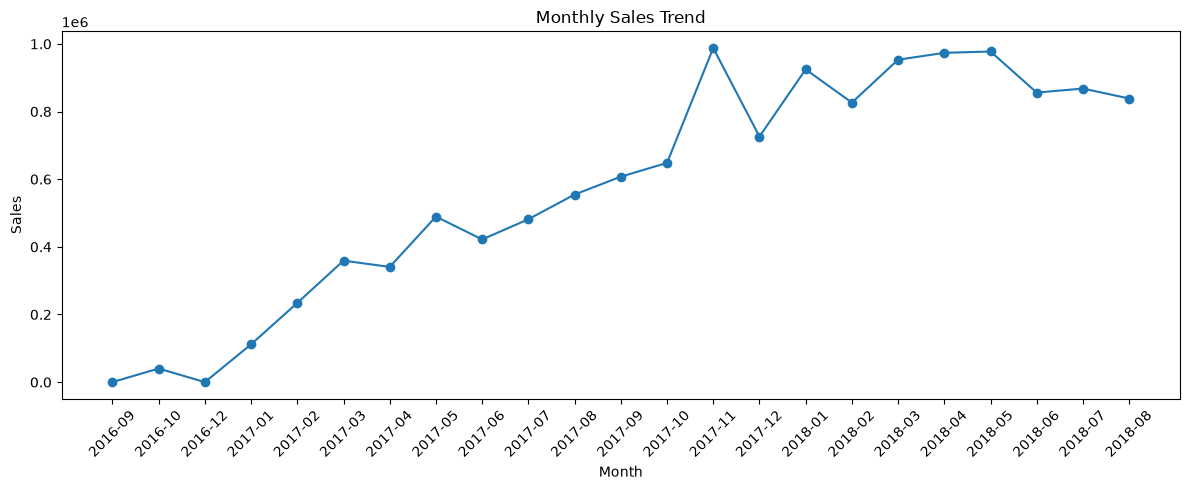

In [49]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["order_month"],
    monthly_sales["price"],
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

In [50]:
monthly_sales.sort_values(
    by="price",
    ascending=False
).head(5)

,order_month,price
13,2017-11,987765.37
19,2018-05,977544.69
18,2018-04,973534.09
17,2018-03,953356.25
15,2018-01,924645.00


In [51]:
monthly_sales["mom_growth_percent"] = (
    monthly_sales["price"].pct_change() * 100
)

In [52]:
monthly_sales.head(10)

,order_month,price,mom_growth_percent
0,2016-09,134.97,NaN
1,2016-10,40325.11,2.977709e+04
2,2016-12,10.90,-9.997297e+01
3,2017-01,111798.36,1.025573e+06
4,2017-02,234223.40,1.095052e+02
5,2017-03,359198.85,5.335737e+01
6,2017-04,340669.68,-5.158471e+00
7,2017-05,489338.25,4.364009e+01
8,2017-06,421923.37,-1.377674e+01
9,2017-07,481604.52,1.414502e+01


## 5. Product and Category Analysis

In [53]:
products = pd.read_csv("../data/olist_products_dataset.csv")

In [54]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [55]:
products.shape

(32951, 9)

In [56]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [57]:
category_translation = pd.read_csv(
    "../data/product_category_name_translation.csv"
)

In [58]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [59]:
products = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

In [60]:
products[[
    "product_id",
    "product_category_name",
    "product_category_name_english"
]].head()

,product_id,product_category_name,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares


In [61]:
sales_products = delivered_sales.merge(
    products[[
        "product_id",
        "product_category_name_english"
    ]],
    on="product_id",
    how="left"
)

In [62]:
sales_products.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_month,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02,garden_tools


In [63]:
sales_products["product_category_name_english"].isnull().sum()

np.int64(1559)

In [64]:
category_sales = (
    sales_products
    .groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

In [65]:
category_sales.head(10)

,product_category_name_english,price
0,health_beauty,1233131.72
1,watches_gifts,1166176.98
2,bed_bath_table,1023434.76
3,sports_leisure,954852.55
4,computers_accessories,888724.61
5,furniture_decor,711927.69
6,housewares,615628.69
7,cool_stuff,610204.10
8,auto,578966.65
9,toys,471286.48


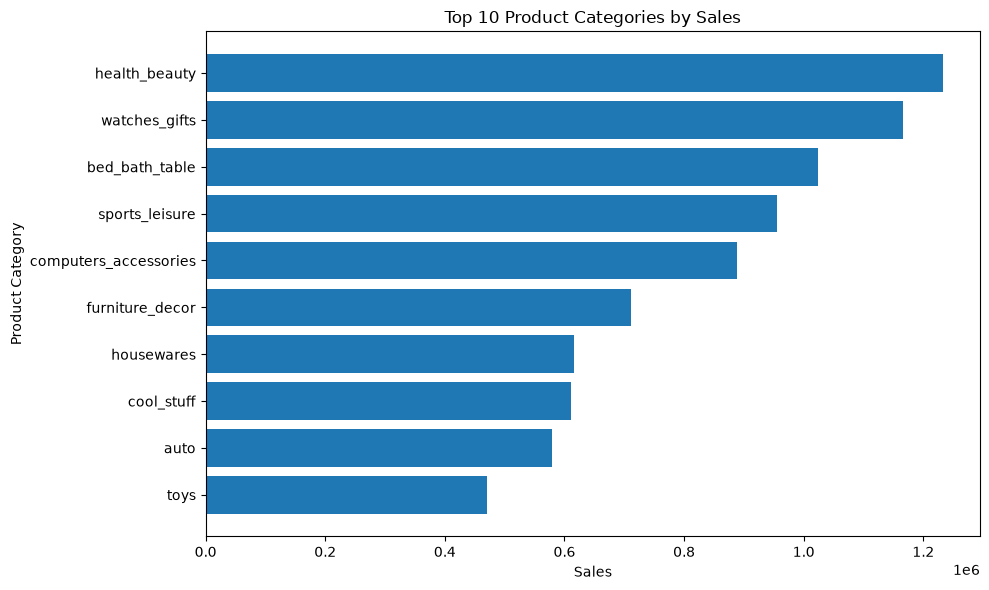

In [66]:
top_10_categories = category_sales.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_categories["product_category_name_english"],
    top_10_categories["price"]
)

plt.gca().invert_yaxis()
plt.title("Top 10 Product Categories by Sales")
plt.xlabel("Sales")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

## 6. Customer Analysis

In [67]:
customer_sales = delivered_sales.merge(
    customers[[
        "customer_id",
        "customer_unique_id",
        "customer_city",
        "customer_state"
    ]],
    on="customer_id",
    how="left"
)

In [68]:
customer_sales.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_month,customer_unique_id,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09,871766c5855e863f6eccc05f988b23cb,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04,eb28e67c4c0b83846050ddfb8a35d051,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01,3818d81c6709e39d06b2738a8d3a2474,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08,af861d436cfc08b2c2ddefd0ba074622,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02,64b576fb70d441e8f1b2d7d446e483c5,varzea paulista,SP


In [69]:
customer_order_counts = (
    customer_sales
    .groupby("customer_unique_id")["order_id"]
    .nunique()
    .reset_index(name="order_count")
)

In [70]:
customer_order_counts.head()

,customer_unique_id,order_count
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [71]:
repeat_customers = customer_order_counts[
    customer_order_counts["order_count"] > 1
]

In [72]:
len(repeat_customers)

2801

In [73]:
len(customer_order_counts)

93358

In [74]:
repeat_customer_rate = (
    len(repeat_customers) / len(customer_order_counts)
) * 100

round(repeat_customer_rate, 2)

3.0

In [75]:
customer_spend = (
    customer_sales
    .groupby("customer_unique_id")["price"]
    .sum()
    .reset_index(name="total_spend")
)

In [76]:
customer_spend.sort_values(
    by="total_spend",
    ascending=False
).head(10)

,customer_unique_id,total_spend
3724,0a0a92112bd4c708ca5fde585afaa872,13440.0
79636,da122df9eeddfedc1dc1f5349a1a690c,7388.0
43168,763c8b1c9c68a0229c42c9fc6f662b93,7160.0
80463,dc4802a71eae9be1dd28f5d788ceb526,6735.0
25436,459bef486812aa25204be022145caa62,6729.0
93081,ff4159b92c40ebe40454e3e6a7c35ed6,6499.0
23411,4007669dec559734d6f53e029e360987,5934.6
87148,eebb5dda148d3893cdaf5b5ca3040ccb,4690.0
26640,48e1ac109decbb87765a3eade6854098,4590.0
59163,a229eba70ec1c2abef51f04987deb7a5,4400.0


In [77]:
state_sales = (
    customer_sales
    .groupby("customer_state")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

In [78]:
state_sales.head(10)

,customer_state,price
0,SP,5067633.16
1,RJ,1759651.13
2,MG,1552481.83
3,RS,728897.47
4,PR,666063.51
5,SC,507012.13
6,BA,493584.14
7,DF,296498.41
8,GO,282836.70
9,ES,268643.45


## 7. Seller Performance Analysis

In [79]:
sellers = pd.read_csv("../data/olist_sellers_dataset.csv")

In [80]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [81]:
sellers.shape

(3095, 4)

In [82]:
sellers.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [83]:
seller_sales = delivered_sales.merge(
    sellers[[
        "seller_id",
        "seller_city",
        "seller_state"
    ]],
    on="seller_id",
    how="left"
)

In [84]:
seller_sales.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_month,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09,volta redonda,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02,loanda,PR


In [85]:
seller_performance = (
    seller_sales
    .groupby("seller_id")
    .agg(
        total_sales=("price", "sum"),
        total_orders=("order_id", "nunique")
    )
    .reset_index()
)

In [86]:
seller_performance.sort_values(
    by="total_sales",
    ascending=False
).head(10)

,seller_id,total_sales,total_orders
834,4869f7a5dfa277a7dca6462dcf3b52b2,226987.93,1124
982,53243585a1d6dc2643021fd1853d8905,217940.44,348
858,4a3ca9315b744ce9f8e9374361493884,196882.12,1772
2903,fa1c13f2614d7b5c4749cbc52fecda94,190917.14,578
1480,7c67e1448b00f6e969d365cea6b010ab,186570.05,973
1504,7e93a43ef30c4f03f38b393420bc753a,165981.49,319
2543,da8622b14eb17ae2831f4ac5b9dab84a,159816.87,1311
1450,7a67c85e85bb2ce8582c35f2203ad736,139658.69,1145
188,1025f0e2d44d7041d6cf58b6550e0bfa,138208.56,910
1758,955fee9216a65b617aa5c0531780ce60,131836.71,1261


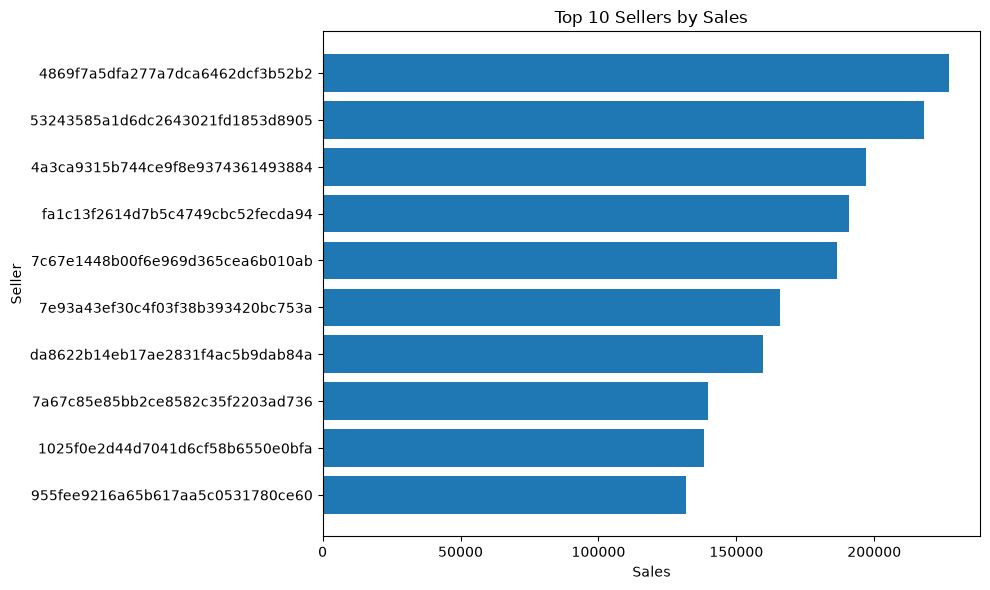

In [87]:
top_sellers = (
    seller_performance
    .sort_values("total_sales", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_sellers["seller_id"],
    top_sellers["total_sales"]
)

plt.gca().invert_yaxis()
plt.title("Top 10 Sellers by Sales")
plt.xlabel("Sales")
plt.ylabel("Seller")

plt.tight_layout()
plt.show()

## 8. Delivery and Customer Review Analysis

In [88]:
reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")

In [89]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [90]:
reviews.shape

(99224, 7)

In [91]:
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [92]:
reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [93]:
reviews["order_id"].duplicated().sum()

np.int64(551)

In [94]:
order_reviews = (
    reviews
    .groupby("order_id")["review_score"]
    .mean()
    .reset_index()
)

In [95]:
order_reviews.head()

,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


In [96]:
delivery_reviews = delivered_orders.merge(
    order_reviews,
    on="order_id",
    how="left"
)

In [97]:
delivery_reviews.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,is_late,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,False,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,False,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,False,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,False,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,False,5.0


In [98]:
delivery_reviews["review_score"].mean()

np.float64(4.156186520855942)

In [99]:
delivery_reviews.groupby("is_late")["review_score"].mean()

is_late
False    4.294311
True     2.566506
Name: review_score, dtype: float64

In [100]:
review_by_delivery = (
    delivery_reviews
    .groupby("is_late")["review_score"]
    .mean()
    .reset_index()
)

review_by_delivery["delivery_status"] = review_by_delivery["is_late"].map({
    False: "On Time",
    True: "Late"
})

review_by_delivery

,is_late,review_score,delivery_status
0,False,4.294311,On Time
1,True,2.566506,Late


In [101]:
delivery_reviews["delay_days"] = (
    delivery_reviews["order_delivered_customer_date"]
    - delivery_reviews["order_estimated_delivery_date"]
).dt.days

In [102]:
delivery_reviews[[
    "order_id",
    "delivery_days",
    "delay_days",
    "is_late",
    "review_score"
]].head()

,order_id,delivery_days,delay_days,is_late,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,8.0,-8.0,False,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,13.0,-6.0,False,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,9.0,-18.0,False,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,13.0,-13.0,False,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2.0,-10.0,False,5.0


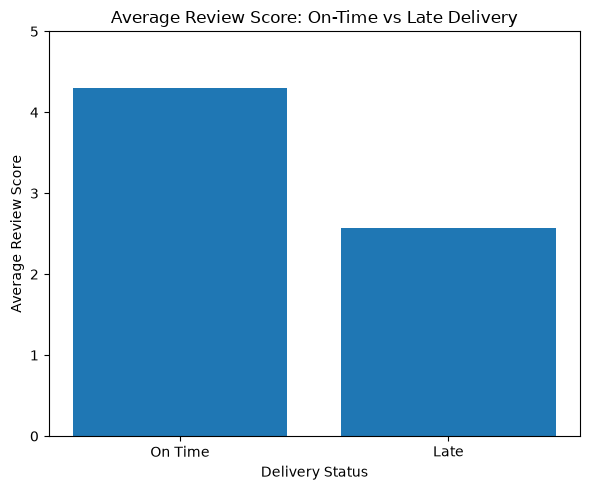

In [103]:
plt.figure(figsize=(6, 5))

plt.bar(
    review_by_delivery["delivery_status"],
    review_by_delivery["review_score"]
)

plt.title("Average Review Score: On-Time vs Late Delivery")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)

plt.tight_layout()
plt.show()

In [104]:
review_distribution = (
    delivery_reviews
    .groupby(["is_late", "review_score"])
    .size()
    .reset_index(name="count")
)

review_distribution

,is_late,review_score,count
0,False,1.000000,5780
1,False,1.500000,7
2,False,2.000000,2314
3,False,2.500000,24
4,False,3.000000,7047
5,False,3.333333,1
6,False,3.500000,20
7,False,4.000000,17923
8,False,4.333333,1
9,False,4.500000,51


In [105]:
review_distribution["percentage"] = (
    review_distribution["count"]
    / review_distribution.groupby("is_late")["count"].transform("sum")
    * 100
)

review_distribution

,is_late,review_score,count,percentage
0,False,1.000000,5780,6.555443
1,False,1.500000,7,0.007939
2,False,2.000000,2314,2.624446
3,False,2.500000,24,0.027220
4,False,3.000000,7047,7.992424
5,False,3.333333,1,0.001134
6,False,3.500000,20,0.022683
7,False,4.000000,17923,20.327545
8,False,4.333333,1,0.001134
9,False,4.500000,51,0.057842


In [106]:
one_star_reviews = review_distribution[
    review_distribution["review_score"] == 1
]

one_star_reviews

,is_late,review_score,count,percentage
0,False,1.0,5780,6.555443
11,True,1.0,3533,46.116695


In [107]:
five_star_reviews = review_distribution[
    review_distribution["review_score"] == 5
]

five_star_reviews

,is_late,review_score,count,percentage
10,False,5.0,55003,62.382189
19,True,5.0,1701,22.203368


In [108]:
average_delivery_days = delivered_orders["delivery_days"].mean()

In [109]:
late_delivery_rate = delivered_orders["is_late"].mean() * 100

In [110]:
average_review_score = delivery_reviews["review_score"].mean()

## 9. KPI Summary

In [111]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Sales",
        "Total Orders",
        "Average Order Value",
        "Repeat Customer Rate (%)",
        "Average Delivery Days",
        "Late Delivery Rate (%)",
        "Average Review Score"
    ],
    "Value": [
        round(total_sales, 2),
        total_orders,
        round(average_order_value, 2),
        round(repeat_customer_rate, 2),
        round(average_delivery_days, 2),
        round(late_delivery_rate, 2),
        round(average_review_score, 2)
    ]
})

kpi_summary

,KPI,Value
0,Total Sales,13221498.11
1,Total Orders,96478.00
2,Average Order Value,137.04
3,Repeat Customer Rate (%),3.00
4,Average Delivery Days,12.09
5,Late Delivery Rate (%),8.11
6,Average Review Score,4.16


In [112]:
kpi_summary.to_csv("../output/kpi_summary.csv", index=False)

In [113]:
monthly_sales.to_csv("../output/monthly_sales.csv", index=False)
category_sales.to_csv("../output/category_sales.csv", index=False)
state_sales.to_csv("../output/state_sales.csv", index=False)
seller_performance.to_csv("../output/seller_performance.csv", index=False)
review_by_delivery.to_csv("../output/review_by_delivery.csv", index=False)

In [114]:
print("Total Sales:", round(total_sales, 2))
print("Total Orders:", total_orders)
print("Average Order Value:", round(average_order_value, 2))
print("Repeat Customer Rate:", round(repeat_customer_rate, 2), "%")
print("Average Delivery Days:", round(average_delivery_days, 2))
print("Late Delivery Rate:", round(late_delivery_rate, 2), "%")
print("Average Review Score:", round(average_review_score, 2))

print("\nTop Sales Month:")
print(monthly_sales.sort_values("price", ascending=False).head(1))

print("\nTop Product Category:")
print(category_sales.head(1))

print("\nTop Customer State:")
print(state_sales.head(1))

print("\nTop Seller:")
print(
    seller_performance
    .sort_values("total_sales", ascending=False)
    .head(1)
)

Total Sales: 13221498.11
Total Orders: 96478
Average Order Value: 137.04
Repeat Customer Rate: 3.0 %
Average Delivery Days: 12.09
Late Delivery Rate: 8.11 %
Average Review Score: 4.16

Top Sales Month:
   order_month      price  mom_growth_percent
13     2017-11  987765.37           52.374694

Top Product Category:
  product_category_name_english       price
0                 health_beauty  1233131.72

Top Customer State:
  customer_state       price
0             SP  5067633.16

Top Seller:
                            seller_id  total_sales  total_orders
834  4869f7a5dfa277a7dca6462dcf3b52b2    226987.93          1124


In [115]:
print("On-Time vs Late Delivery Review Score")
print(review_by_delivery[["delivery_status", "review_score"]])

On-Time vs Late Delivery Review Score
  delivery_status  review_score
0         On Time      4.294311
1            Late      2.566506


## 10. SQL Analysis and Data Validation

In [116]:
import sqlite3

In [117]:
conn = sqlite3.connect(":memory:")

In [118]:
customers.to_sql("customers", conn, index=False, if_exists="replace")
orders.to_sql("orders", conn, index=False, if_exists="replace")
order_items.to_sql("order_items", conn, index=False, if_exists="replace")
products.to_sql("products", conn, index=False, if_exists="replace")
sellers.to_sql("sellers", conn, index=False, if_exists="replace")
reviews.to_sql("reviews", conn, index=False, if_exists="replace")

99224

In [119]:
pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table';
""", conn)

,name
0,customers
1,orders
2,order_items
3,products
4,sellers
5,reviews


In [120]:
pd.read_sql("""
SELECT *
FROM customers
LIMIT 5;
""", conn)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [121]:
pd.read_sql("""
SELECT
    customer_state,
    COUNT(*) AS customer_count
FROM customers
GROUP BY customer_state
ORDER BY customer_count DESC;
""", conn)

,customer_state,customer_count
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


In [122]:
pd.read_sql("""
SELECT
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(SUM(oi.price), 2) AS total_sales
FROM orders o
JOIN order_items oi
    ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered';
""", conn)

,total_orders,total_sales
0,96478,13221498.11


In [123]:
pd.read_sql("""
SELECT
    strftime('%Y-%m', o.order_purchase_timestamp) AS order_month,
    ROUND(SUM(oi.price), 2) AS total_sales
FROM orders o
JOIN order_items oi
    ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY order_month
ORDER BY order_month;
""", conn)

,order_month,total_sales
0,2016-09,134.97
1,2016-10,40325.11
2,2016-12,10.90
3,2017-01,111798.36
4,2017-02,234223.40
5,2017-03,359198.85
6,2017-04,340669.68
7,2017-05,489338.25
8,2017-06,421923.37
9,2017-07,481604.52


In [124]:
pd.read_sql("""
SELECT
    p.product_category_name_english AS category,
    ROUND(SUM(oi.price), 2) AS total_sales
FROM order_items oi
JOIN orders o
    ON oi.order_id = o.order_id
JOIN products p
    ON oi.product_id = p.product_id
WHERE o.order_status = 'delivered'
  AND p.product_category_name_english IS NOT NULL
GROUP BY p.product_category_name_english
ORDER BY total_sales DESC
LIMIT 10;
""", conn)

,category,total_sales
0,health_beauty,1233131.72
1,watches_gifts,1166176.98
2,bed_bath_table,1023434.76
3,sports_leisure,954852.55
4,computers_accessories,888724.61
5,furniture_decor,711927.69
6,housewares,615628.69
7,cool_stuff,610204.10
8,auto,578966.65
9,toys,471286.48


In [125]:
pd.read_sql("""
SELECT
    oi.seller_id,
    ROUND(SUM(oi.price), 2) AS total_sales,
    COUNT(DISTINCT oi.order_id) AS total_orders
FROM order_items oi
JOIN orders o
    ON oi.order_id = o.order_id
WHERE o.order_status = 'delivered'
GROUP BY oi.seller_id
ORDER BY total_sales DESC
LIMIT 10;
""", conn)

,seller_id,total_sales,total_orders
0,4869f7a5dfa277a7dca6462dcf3b52b2,226987.93,1124
1,53243585a1d6dc2643021fd1853d8905,217940.44,348
2,4a3ca9315b744ce9f8e9374361493884,196882.12,1772
3,fa1c13f2614d7b5c4749cbc52fecda94,190917.14,578
4,7c67e1448b00f6e969d365cea6b010ab,186570.05,973
5,7e93a43ef30c4f03f38b393420bc753a,165981.49,319
6,da8622b14eb17ae2831f4ac5b9dab84a,159816.87,1311
7,7a67c85e85bb2ce8582c35f2203ad736,139658.69,1145
8,1025f0e2d44d7041d6cf58b6550e0bfa,138208.56,910
9,955fee9216a65b617aa5c0531780ce60,131836.71,1261


In [126]:
pd.read_sql("""
WITH monthly_sales AS (
    SELECT
        strftime('%Y-%m', o.order_purchase_timestamp) AS order_month,
        SUM(oi.price) AS total_sales
    FROM orders o
    JOIN order_items oi
        ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY order_month
)

SELECT
    order_month,
    ROUND(total_sales, 2) AS total_sales,
    ROUND(
        LAG(total_sales) OVER (ORDER BY order_month),
        2
    ) AS previous_month_sales
FROM monthly_sales
ORDER BY order_month;
""", conn)

,order_month,total_sales,previous_month_sales
0,2016-09,134.97,NaN
1,2016-10,40325.11,134.97
2,2016-12,10.90,40325.11
3,2017-01,111798.36,10.90
4,2017-02,234223.40,111798.36
5,2017-03,359198.85,234223.40
6,2017-04,340669.68,359198.85
7,2017-05,489338.25,340669.68
8,2017-06,421923.37,489338.25
9,2017-07,481604.52,421923.37


In [127]:
pd.read_sql("""
WITH monthly_sales AS (
    SELECT
        strftime('%Y-%m', o.order_purchase_timestamp) AS order_month,
        SUM(oi.price) AS total_sales
    FROM orders o
    JOIN order_items oi
        ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY order_month
),

sales_with_previous AS (
    SELECT
        order_month,
        total_sales,
        LAG(total_sales) OVER (ORDER BY order_month) AS previous_month_sales
    FROM monthly_sales
)

SELECT
    order_month,
    ROUND(total_sales, 2) AS total_sales,
    ROUND(previous_month_sales, 2) AS previous_month_sales,
    ROUND(
        ((total_sales - previous_month_sales)
        / previous_month_sales) * 100,
        2
    ) AS mom_growth_percent
FROM sales_with_previous
ORDER BY order_month;
""", conn)

,order_month,total_sales,previous_month_sales,mom_growth_percent
0,2016-09,134.97,NaN,NaN
1,2016-10,40325.11,134.97,29777.09
2,2016-12,10.90,40325.11,-99.97
3,2017-01,111798.36,10.90,1025573.03
4,2017-02,234223.40,111798.36,109.51
5,2017-03,359198.85,234223.40,53.36
6,2017-04,340669.68,359198.85,-5.16
7,2017-05,489338.25,340669.68,43.64
8,2017-06,421923.37,489338.25,-13.78
9,2017-07,481604.52,421923.37,14.15


In [128]:
pd.read_sql("""
WITH category_sales AS (
    SELECT
        p.product_category_name_english AS category,
        SUM(oi.price) AS total_sales
    FROM order_items oi
    JOIN orders o
        ON oi.order_id = o.order_id
    JOIN products p
        ON oi.product_id = p.product_id
    WHERE o.order_status = 'delivered'
      AND p.product_category_name_english IS NOT NULL
    GROUP BY p.product_category_name_english
)

SELECT
    category,
    ROUND(total_sales, 2) AS total_sales,
    RANK() OVER (
        ORDER BY total_sales DESC
    ) AS sales_rank
FROM category_sales
ORDER BY sales_rank
LIMIT 15;
""", conn)

,category,total_sales,sales_rank
0,health_beauty,1233131.72,1
1,watches_gifts,1166176.98,2
2,bed_bath_table,1023434.76,3
3,sports_leisure,954852.55,4
4,computers_accessories,888724.61,5
5,furniture_decor,711927.69,6
6,housewares,615628.69,7
7,cool_stuff,610204.10,8
8,auto,578966.65,9
9,toys,471286.48,10


In [129]:
pd.read_sql("""
WITH customer_orders AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) AS total_orders
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
)

SELECT
    COUNT(*) AS total_customers,
    SUM(
        CASE
            WHEN total_orders > 1 THEN 1
            ELSE 0
        END
    ) AS repeat_customers,
    ROUND(
        100.0 * SUM(
            CASE
                WHEN total_orders > 1 THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS repeat_customer_rate
FROM customer_orders;
""", conn)

,total_customers,repeat_customers,repeat_customer_rate
0,93358,2801,3.0


In [130]:
pd.read_sql("""
SELECT
    c.customer_unique_id,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(SUM(oi.price), 2) AS total_spend
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
JOIN order_items oi
    ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_unique_id
ORDER BY total_spend DESC
LIMIT 10;
""", conn)

,customer_unique_id,total_orders,total_spend
0,0a0a92112bd4c708ca5fde585afaa872,1,13440.0
1,da122df9eeddfedc1dc1f5349a1a690c,2,7388.0
2,763c8b1c9c68a0229c42c9fc6f662b93,1,7160.0
3,dc4802a71eae9be1dd28f5d788ceb526,1,6735.0
4,459bef486812aa25204be022145caa62,1,6729.0
5,ff4159b92c40ebe40454e3e6a7c35ed6,1,6499.0
6,4007669dec559734d6f53e029e360987,1,5934.6
7,eebb5dda148d3893cdaf5b5ca3040ccb,1,4690.0
8,48e1ac109decbb87765a3eade6854098,1,4590.0
9,a229eba70ec1c2abef51f04987deb7a5,1,4400.0


In [131]:
pd.read_sql("""
WITH customer_summary AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) AS total_orders,
        SUM(oi.price) AS total_spend
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
    JOIN order_items oi
        ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
)

SELECT
    customer_unique_id,
    total_orders,
    ROUND(total_spend, 2) AS total_spend,
    CASE
        WHEN total_orders >= 3 THEN 'Frequent Customer'
        WHEN total_orders = 2 THEN 'Repeat Customer'
        ELSE 'One-Time Customer'
    END AS customer_segment
FROM customer_summary
ORDER BY total_spend DESC
LIMIT 20;
""", conn)

,customer_unique_id,total_orders,total_spend,customer_segment
0,0a0a92112bd4c708ca5fde585afaa872,1,13440.00,One-Time Customer
1,da122df9eeddfedc1dc1f5349a1a690c,2,7388.00,Repeat Customer
2,763c8b1c9c68a0229c42c9fc6f662b93,1,7160.00,One-Time Customer
3,dc4802a71eae9be1dd28f5d788ceb526,1,6735.00,One-Time Customer
4,459bef486812aa25204be022145caa62,1,6729.00,One-Time Customer
5,ff4159b92c40ebe40454e3e6a7c35ed6,1,6499.00,One-Time Customer
6,4007669dec559734d6f53e029e360987,1,5934.60,One-Time Customer
7,eebb5dda148d3893cdaf5b5ca3040ccb,1,4690.00,One-Time Customer
8,48e1ac109decbb87765a3eade6854098,1,4590.00,One-Time Customer
9,a229eba70ec1c2abef51f04987deb7a5,1,4400.00,One-Time Customer


In [132]:
pd.read_sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT customer_id) AS unique_customer_ids
FROM customers;
""", conn)

,total_rows,unique_customer_ids
0,99441,99441


In [133]:
pd.read_sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id) AS unique_orders
FROM orders;
""", conn)

,total_rows,unique_orders
0,99441,99441


In [134]:
pd.read_sql("""
SELECT
    SUM(CASE WHEN order_id IS NULL THEN 1 ELSE 0 END) AS missing_order_id,
    SUM(CASE WHEN product_id IS NULL THEN 1 ELSE 0 END) AS missing_product_id,
    SUM(CASE WHEN seller_id IS NULL THEN 1 ELSE 0 END) AS missing_seller_id,
    SUM(CASE WHEN price IS NULL THEN 1 ELSE 0 END) AS missing_price
FROM order_items;
""", conn)

,missing_order_id,missing_product_id,missing_seller_id,missing_price
0,0,0,0,0


In [135]:
sql_kpis = pd.read_sql("""
SELECT
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(SUM(oi.price), 2) AS total_sales
FROM orders o
JOIN order_items oi
    ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered';
""", conn)

sql_kpis

,total_orders,total_sales
0,96478,13221498.11


In [136]:
print("Python Total Orders:", total_orders)
print("SQL Total Orders:", sql_kpis.loc[0, "total_orders"])

print("Python Total Sales:", round(total_sales, 2))
print("SQL Total Sales:", sql_kpis.loc[0, "total_sales"])

Python Total Orders: 96478
SQL Total Orders: 96478
Python Total Sales: 13221498.11
SQL Total Sales: 13221498.11


In [137]:
print(
    "Order Count Difference:",
    total_orders - sql_kpis.loc[0, "total_orders"]
)

print(
    "Sales Difference:",
    round(total_sales, 2) - sql_kpis.loc[0, "total_sales"]
)

Order Count Difference: 0
Sales Difference: 0.0


In [138]:
pd.read_sql("""
SELECT
    COUNT(*) AS unmatched_orders
FROM orders o
LEFT JOIN customers c
    ON o.customer_id = c.customer_id
WHERE c.customer_id IS NULL;
""", conn)

,unmatched_orders
0,0


In [139]:
pd.read_sql("""
SELECT
    COUNT(*) AS unmatched_order_items
FROM order_items oi
LEFT JOIN orders o
    ON oi.order_id = o.order_id
WHERE o.order_id IS NULL;
""", conn)

,unmatched_order_items
0,0


In [140]:
pd.read_sql("""
SELECT
    COUNT(*) AS unmatched_products
FROM order_items oi
LEFT JOIN products p
    ON oi.product_id = p.product_id
WHERE p.product_id IS NULL;
""", conn)

,unmatched_products
0,0


In [141]:
pd.read_sql("""
SELECT
    COUNT(*) AS unmatched_sellers
FROM order_items oi
LEFT JOIN sellers s
    ON oi.seller_id = s.seller_id
WHERE s.seller_id IS NULL;
""", conn)

,unmatched_sellers
0,0


In [142]:
pd.read_sql("""
SELECT
    c.customer_state,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(SUM(oi.price), 2) AS total_sales,
    ROUND(AVG(oi.price), 2) AS average_item_price
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
JOIN order_items oi
    ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_state
ORDER BY total_sales DESC
LIMIT 10;
""", conn)

,customer_state,total_orders,total_sales,average_item_price
0,SP,40501,5067633.16,109.10
1,RJ,12350,1759651.13,124.42
2,MG,11354,1552481.83,120.20
3,RS,5345,728897.47,118.83
4,PR,4923,666063.51,117.91
5,SC,3546,507012.13,123.75
6,BA,3256,493584.14,134.02
7,DF,2080,296498.41,125.90
8,GO,1957,282836.70,124.21
9,ES,1995,268643.45,120.74


In [143]:
pd.read_sql("""
WITH order_reviews AS (
    SELECT
        order_id,
        AVG(review_score) AS review_score
    FROM reviews
    GROUP BY order_id
),

delivery_analysis AS (
    SELECT
        o.order_id,
        CASE
            WHEN julianday(o.order_delivered_customer_date)
                 > julianday(o.order_estimated_delivery_date)
            THEN 'Late'
            ELSE 'On Time'
        END AS delivery_status,
        r.review_score
    FROM orders o
    LEFT JOIN order_reviews r
        ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
)

SELECT
    delivery_status,
    COUNT(*) AS total_orders,
    ROUND(AVG(review_score), 2) AS average_review_score
FROM delivery_analysis
GROUP BY delivery_status;
""", conn)

,delivery_status,total_orders,average_review_score
0,Late,7826,2.57
1,On Time,88644,4.29


## 11. Key Business Insights

- November 2017 recorded the highest monthly sales during the analysis period.
- Health & Beauty was the highest-performing product category by sales.
- São Paulo (SP) generated the highest sales among customer states.
- The repeat customer rate was approximately 3%, indicating that most customers purchased only once.
- Average delivery time was approximately 12 days, while about 8% of delivered orders arrived later than the estimated delivery date.
- On-time deliveries received an average review score of approximately 4.29, compared with about 2.57 for late deliveries, indicating that late delivery was associated with lower customer satisfaction.